**<h1> Manipulating Images </h1>**


Estimated time needed: **30** minutes


<h2>Objectives</h2>


In this lab, you will learn how to manipulate images, OpenCV image Arrays. You will learn how to copy an image to avoid aliasing. We will cover flipping images and cropping images. You will also learn to change pixel images; this will allow you to draw shapes, write text and superimpose images over other images.


<ul>
    <li><a href='#MI'>Manipulating Images </a>
        <ul>
            <li>Copying Images  </li>
            <li>Fliping Images </li>
            <li>Cropping an Image </li>
            <li>Changing Specific Image Pixels </li>
     
  
    
</ul>


----


Tải xuống các hình ảnh cho phòng thí nghiệm


In [ ]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/cat.png -O cat.png
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png -O lenna.png
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/baboon.png -O baboon.png

Chúng ta sẽ sử dụng các hàm đã nhập này trong phòng thí nghiệm.



In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

Nhập thư viện: plt, cv2,np

## Copying Images


Nếu bạn muốn gán lại một mảng cho một biến khác, bạn nên sử dụng phương thức `copy`. Nếu chúng ta không áp dụng phương thức `copy()`, biến đó sẽ vẫn trỏ đến cùng một vị trí trong bộ nhớ. Hãy xem xét mảng sau:

In [ ]:
baboon = cv2.imread("baboon.png")
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(baboon, cv2.COLOR_BGR2RGB))
plt.show()

Nếu chúng ta không sử dụng phương thức `copy()`, biến mới sẽ trỏ đến cùng một vị trí trong bộ nhớ:

In [ ]:
A = baboon

Chúng ta sử dụng hàm `id` để tìm địa chỉ bộ nhớ của đối tượng; ta thấy nó giống với mảng gốc.


In [ ]:
id(A)==id(baboon)
id(A)

Nếu ta áp dụng phương thức `copy()`, địa chỉ bộ nhớ sẽ khác.

In [ ]:
B = baboon.copy()
id(B)==id(baboon)

Khi chúng ta không áp dụng phương thức `copy()`, biến sẽ trỏ đến cùng một vị trí trong bộ nhớ. Hãy xem xét mảng `baboon`, nếu ta đặt tất cả các giá trị của nó bằng 0, thì tất cả các giá trị trong `A` cũng sẽ bằng 0. Điều này là do `baboon` và `A` cùng trỏ đến một vị trí trong bộ nhớ, nhưng `B` sẽ không bị ảnh hưởng.

In [ ]:
baboon[:,:,] = 0

In [ ]:
plt.figure(figsize=(10,10))
plt.subplot(121)
plt.imshow(cv2.cvtColor(baboon, cv2.COLOR_BGR2RGB))
plt.title("baboon")
plt.subplot(122)
plt.imshow(cv2.cvtColor(A, cv2.COLOR_BGR2RGB))
plt.title("array A")
plt.show()

Ta thấy chúng giống nhau, điều này được gọi là bí danh. Bí danh xảy ra bất cứ khi nào giá trị của một biến được gán cho một biến khác vì biến chỉ là tên lưu trữ tham chiếu đến giá trị. Ta cũng có thể so sánh <code>baboon</code> và mảng <code>B</code>:

In [ ]:
plt.figure(figsize=(10,10))
plt.subplot(121)
plt.imshow(cv2.cvtColor(baboon, cv2.COLOR_BGR2RGB))
plt.title("baboon")
plt.subplot(122)
plt.imshow(cv2.cvtColor(B, cv2.COLOR_BGR2RGB))
plt.title("array B")
plt.show()

Chúng khác nhau vì chúng sử dụng phương pháp sao chép.

## Fliping Images


Lật ảnh là quá trình sắp xếp lại chỉ số của các pixel sao cho làm thay đổi hướng của ảnh. Hãy xem hình ảnh sau:

In [ ]:
image = cv2.imread("cat.png")
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

Chúng ta có thể chuyển đổi nó thành mảng và tìm ra hình dạng:

In [ ]:
width, height,C=image.shape
print('width, height,C',width, height,C)

Hãy lật nó, tức là xoay theo chiều dọc. Đầu tiên, chúng ta tạo một mảng có kích thước bằng nhau thuộc kiểu ảnh bit <code>np.uint8</code>.

In [ ]:
array_flip = np.zeros((width, height,C),dtype=np.uint8)

Chúng ta gán hàng pixel đầu tiên của mảng gốc cho hàng cuối cùng của mảng mới. Chúng ta lặp lại quá trình này cho mỗi hàng, tăng số thứ tự hàng của mảng gốc và giảm chỉ số hàng của mảng mới, gán các pixel tương ứng.

In [ ]:
for i,row in enumerate(image):
        array_flip[width-1-i,:,:]=row

Chúng tôi vẽ kết quả

In [ ]:
plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(array_flip, cv2.COLOR_BGR2RGB))
plt.show()

<code>OpenCV</code>có nhiều cách để lật ảnh, chúng ta có thể sử dụng hàm <code>flip()</code>; chúng ta có mảng ảnh đầu vào. Tham số là <code>flipCode</code>

là giá trị cho biết loại lật mà chúng ta muốn thực hiện;

<li><code>flipcode</code> = 0: lật dọc quanh trục x</li>
<li><code>flipcode</code> > 0: lật ngang quanh trục y (giá trị dương)</li>
<li><code>flipcode</code>&#60 0: lật dọc và ngang, lật quanh cả hai trục (giá trị âm)</li>
Hãy áp dụng các <code>flipcode</code> khác nhau trong một vòng lặp:

In [ ]:
for flipcode in [0,1,-1]:
    im_flip =  cv2.flip(image,flipcode )
    plt.imshow(cv2.cvtColor(im_flip,cv2.COLOR_BGR2RGB))
    plt.title("flipcode: "+str(flipcode))
    plt.show()

Chúng ta cũng có thể sử dụng hàm `rotate()`. Tham số là một số nguyên cho biết loại lật mà chúng ta muốn thực hiện.

In [ ]:
im_flip = cv2.rotate(image,0)
plt.imshow(cv2.cvtColor(im_flip,cv2.COLOR_BGR2RGB))
plt.show()

Mô-đun OpenCV có các thuộc tính tích hợp mô tả loại lật, giá trị chỉ là các số nguyên. Một số được hiển thị trong <code>dict</code> sau:

In [ ]:
flip = {"ROTATE_90_CLOCKWISE":cv2.ROTATE_90_CLOCKWISE,"ROTATE_90_COUNTERCLOCKWISE":cv2.ROTATE_90_COUNTERCLOCKWISE,"ROTATE_180":cv2.ROTATE_180}

Ta thấy các khóa chỉ là một số nguyên.


In [ ]:
flip["ROTATE_90_CLOCKWISE"]

Chúng ta có thể vẽ đồ thị từng kết quả đầu ra bằng cách sử dụng các giá trị tham số khác nhau.

In [ ]:
for key, value in flip.items():
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("orignal")
    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(cv2.rotate(image,value), cv2.COLOR_BGR2RGB))
    plt.title(key)
    plt.show()

 ## Cropping an Image


Cắt xén là "cắt bỏ" một phần của hình ảnh và loại bỏ phần còn lại; chúng ta có thể cắt xén bằng cách sử dụng mảng. Hãy bắt đầu với việc cắt xén theo chiều dọc; biến <code>upper</code> là hàng đầu tiên mà chúng ta muốn giữ lại trong hình ảnh, biến <code>lower</code> là hàng cuối cùng mà chúng ta muốn giữ lại. Sau đó, chúng ta sử dụng phép cắt lát để thu được hình ảnh mới.

In [ ]:
upper = 150
lower = 400
crop_top = image[upper: lower,:,:]
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(crop_top, cv2.COLOR_BGR2RGB))
plt.show()

Hãy xem xét mảng <code>crop_top</code>, chúng ta cũng có thể cắt theo chiều ngang. Biến `right` là cột đầu tiên mà chúng ta muốn đưa vào ảnh, biến `left` là cột cuối cùng mà chúng ta muốn đưa vào ảnh.

In [ ]:
left = 150
right = 400
crop_horizontal = crop_top[: ,left:right,:]
plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(crop_horizontal, cv2.COLOR_BGR2RGB))
plt.show()

## Changing Specific Image Pixels


Chúng ta có thể thay đổi các pixel cụ thể của ảnh bằng cách sử dụng chỉ mục mảng; ví dụ, chúng ta có thể đặt tất cả các kênh trong ảnh gốc đã cắt về 0:

In [ ]:
array_sq = np.copy(image)
array_sq[upper:lower,left:right,:] = 0

Chúng ta có thể so sánh kết quả với hình ảnh mới.

In [ ]:
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
plt.title("orignal")
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(array_sq,cv2.COLOR_BGR2RGB))
plt.title("Altered Image")
plt.show()

Chúng ta cũng có thể tạo các hình dạng và sử dụng phương thức `rectangle` trong `OpenCV`. Tham số `pt1` là tọa độ trên cùng bên trái của hình chữ nhật: `(trái, trên)` hoặc `(x_0, y_0)`, `pt2` là tọa độ dưới cùng bên phải: `(phải, dưới)` hoặc `(x_1, y_1)`. Tham số `color` là một bộ giá trị biểu thị cường độ của mỗi kênh (xanh lam, xanh lục, đỏ). Cuối cùng, chúng ta có độ dày của đường kẻ.

In [ ]:
start_point, end_point = (left, upper),(right, lower)
image_draw = np.copy(image)
cv2.rectangle(image_draw, pt1=start_point, pt2=end_point, color=(0, 255, 0), thickness=3)
plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(image_draw, cv2.COLOR_BGR2RGB))
plt.show()

Chúng ta có thể phủ văn bản lên hình ảnh bằng cách sử dụng hàm `putText` với các giá trị tham số sau:

<li><code>img</code>: Mảng hình ảnh </li>
<li><code>text</code>: Chuỗi văn bản cần được phủ lên</li>
<li><code>org</code>: Góc dưới bên trái của chuỗi văn bản trong hình ảnh</li>
<li><code>fontFace</code>: Loại phông chữ </li>
<li><code>fontScale</code>: Tỷ lệ phông chữ</li>
<li><code>color</code>: Màu chữ</li>
<li><code>thickness</code>: Độ dày của các đường kẻ dùng để vẽ chữ</li>
<li><code>lineType:</code> Loại đường kẻ</li>

In [ ]:
image_draw=cv2.putText(img=image,text='Stuff',org=(10,500),color=(255,255,255),fontFace=4,fontScale=5,thickness=2)
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(image_draw,cv2.COLOR_BGR2RGB))
plt.show()

### Question-4:
Use the image baboon.png from this lab or take any image you like.

Open the image and create a OpenCV Image object called `im`, convert the image from BGR format to RGB format, flip `im` vertically around the x-axis and create an image called `im_flip`, mirror `im` by flipping it horizontally around the y-axis and create an image called `im_mirror`, finally plot both images


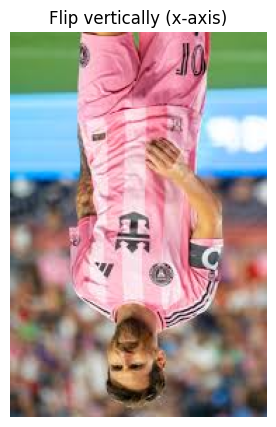

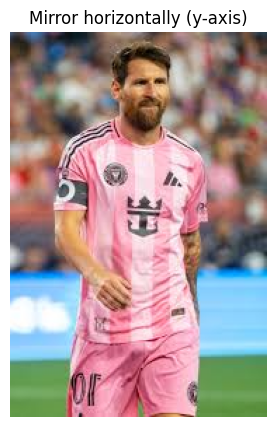

In [1]:
# write your code here
import cv2
import matplotlib.pyplot as plt

# Đọc ảnh
im = cv2.imread("Messi.jpg")

# Flip ảnh theo trục x (lật dọc)
im_flip = cv2.flip(im, 0)

# Mirror ảnh theo trục y (lật ngang)
im_mirror = cv2.flip(im, 1)

# Hiển thị ảnh flip
plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(im_flip, cv2.COLOR_BGR2RGB))
plt.title("Flip vertically (x-axis)")
plt.axis("off")
plt.show()

# Hiển thị ảnh mirror
plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(im_mirror, cv2.COLOR_BGR2RGB))
plt.title("Mirror horizontally (y-axis)")
plt.axis("off")
plt.show()


Double-click **here** for a hint.

<!-- The hint is below:

im_flip =  cv2.flip(baboon,0)
im_mirror =  cv2.flip(baboon, 1)

-->


Double-click **here** for the solution.

<!-- The answer is below:

im = cv2.imread("baboon.png")

im_flip =  cv2.flip(im, 0)
plt.imshow(cv2.cvtColor(im_flip, cv2.COLOR_BGR2RGB))
plt.show()

im_mirror =  cv2.flip(im, 1)
plt.imshow(cv2.cvtColor(im_mirror, cv2.COLOR_BGR2RGB))
plt.show()

-->


# References


[1]  Images were taken from: https://homepages.cae.wisc.edu/~ece533/images/
    
[2]  <a href='https://pillow.readthedocs.io/en/stable/index.html'>Pillow Docs</a>

[3]  <a href='https://opencv.org/'>Open CV</a>

[4] Gonzalez, Rafael C., and Richard E. Woods. "Digital image processing." (2017).


<!--<h2>Change Log</h2>-->


<!--
<table>
    <tr>
        <th>Date (YYYY-MM-DD)</th>
        <th>Version</th>
        <th>Changed By</th>
        <th>Change Description</th>
    </tr>
    <tr>
        <td>2020-07-20</td>
        <td>0.2</td>
        <td>Azim</td>
        <td>Modified Multiple Areas</td>
    </tr>
    <tr>
        <td>2020-07-17</td>
        <td>0.1</td>
        <td>Azim</td>
        <td>Created Lab Template</td>
    </tr>
    <tr>
        <td>2021-03-06</td>
        <td>0.3</td>
        <td>Nayef</td>
        <td>Modified some codes</td>
    </tr>
</table>
-->


<h3 align="center"> &#169; IBM Corporation. All rights reserved. <h3/>
